РЕЗУЛЬТАТЫ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ
              precision    recall  f1-score   support

           0       0.86      0.55      0.67        11
           1       0.64      0.82      0.72        11
           2       0.83      0.91      0.87        11

    accuracy                           0.76        33
   macro avg       0.78      0.76      0.75        33
weighted avg       0.78      0.76      0.75        33

Accuracy: 0.7575757575757576

СРАВНЕНИЕ С ЭВРИСТИКОЙ
Точность эвристики: 0.6786
Точность ML модели: 0.7576


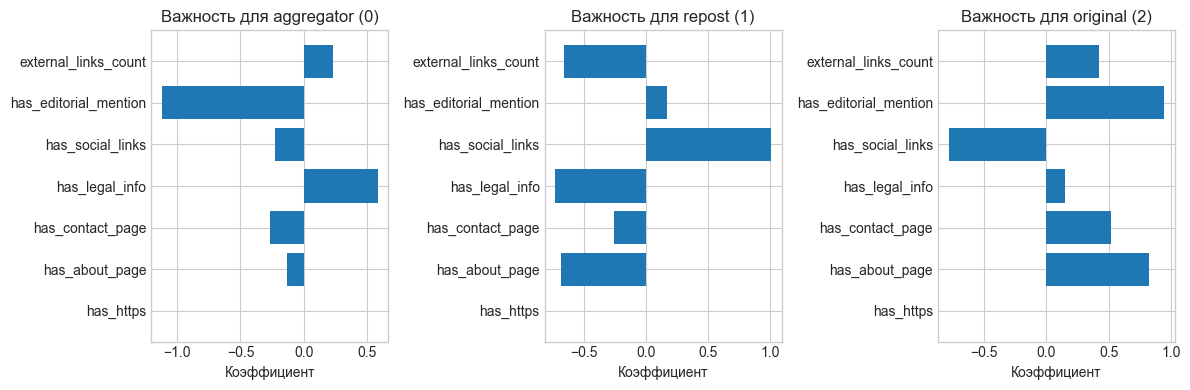

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

from imblearn.over_sampling import RandomOverSampler

df = pd.read_csv("sites_data_labeled1.csv", encoding='utf-8-sig', sep=';')

# Признаки (X)
feature_cols = ['has_https', 'has_about_page', 'has_contact_page',
                'has_legal_info', 'has_social_links', 'has_editorial_mention',
                'external_links_count']

# Преобразуем True/False в 1/0
for col in feature_cols:
    if df[col].dtype == bool:
        df[col] = df[col].astype(int)

X = df[feature_cols]
y = df['class']

# балансировка классов (апсемплинг)
oversampler = RandomOverSampler(random_state=123)
X_resampled, y_resampled = oversampler.fit_resample(X, y)

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

# Разделение
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_resampled, test_size=0.3, random_state=42, stratify=y_resampled)

# Обучение
model = LogisticRegression( max_iter=1000, C=1.0)
model.fit(X_train, y_train)

# Оценка
y_pred = model.predict(X_test)
print("=" * 50)
print("РЕЗУЛЬТАТЫ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ")
print("=" * 50)
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

# Сравнение с эвристикой
def heuristic_to_class(rating):
    if rating >= 4:
        return 2
    elif rating == 3:
        return 1
    else:
        return 0

df['heuristic_class'] = df['heuristic_rating'].apply(heuristic_to_class)
heuristic_accuracy = accuracy_score(df['class'], df['heuristic_class'])
print("\n" + "=" * 50)
print("СРАВНЕНИЕ С ЭВРИСТИКОЙ")
print("=" * 50)
print(f"Точность эвристики: {heuristic_accuracy:.4f}")
print(f"Точность ML модели: {accuracy_score(y_test, y_pred):.4f}")

# Анализ важности признаков
import matplotlib.pyplot as plt
#plt.style.use('default')  # Включает стандартную чистую светлую тему
# или
plt.style.use('seaborn-v0_8-whitegrid') # Делает красивую светлую сетку
import numpy as np

coefs = model.coef_
feature_names = feature_cols
class_names = ['aggregator (0)', 'repost (1)', 'original (2)']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, class_name in enumerate(class_names):
    axes[i].barh(feature_names, coefs[i])
    axes[i].set_title(f'Важность для {class_name}')
    axes[i].set_xlabel('Коэффициент')
plt.tight_layout()
# Вместо plt.savefig('my_plot.png') пиши:
plt.savefig('feature_importance.png', facecolor='white', edgecolor='none', bbox_inches='tight', dpi=300)
plt.show()
